# **Lab 02:** Creating your own CNN with PyTorch

### **General Instructions**

- In this lab, you'll create your own CNN in order to surpass an accuracy of 70% on CIFAR-10.

### **System Diagram Requirement**

You must include a **diagram of your system pipeline** showing the CNN architecture.

This diagram is **required** to understand your model logic.

You can draw it digitally, use any Pyhton library, or by hand and include an image.

If your diagram was created assisted by GenAI, also include the `promt` used in the next block. If the generated system diagram is not clear or you cannot interpret it, adjust the prompt as needed or draw it by hand.

*If you used GenAI, write your prompt here..*

Puedes ayudarme creado un diagrama explicando esta arquitectura , considera que el input es CIFAR10 CNN(  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)  (flatten): Flatten(start_dim=1, end_dim=-1)  (fc1): Linear(in_features=4096, out_features=256, bias=True)  (relu): ReLU()  (fc2): Linear(in_features=256, out_features=10, bias=True))

### **Load the CIFAR-10 dataset**

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

teste_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train = True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train = False, download=True, transform=teste_transform)


loader_train = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
loader_test = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
print(f"This is the lenght of the train dataset: {len(trainset)}")
print(f"This is the lenght of the train loader: {len(loader_train)}")

This is the lenght of the train dataset: 50000
This is the lenght of the train loader: 391


### **Create your CNN with PyTorch and train it on the CIFAR-10 dataset**

In [7]:
from torch.nn import Module, Conv2d, MaxPool2d, Linear, Flatten, ReLU
class CNN(Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = MaxPool2d(kernel_size=2, stride=2)
        self.flatten = Flatten()
        self.fc1 = Linear(64 * 8 * 8, 256)
        self.relu = ReLU()
        self.fc2 = Linear(256, 10)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

 
model = CNN()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
print(model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [8]:
type(loader_train)
print(loader_train)

In [9]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(loader_train): 
        images = images.to('cuda' if torch.cuda.is_available() else 'cpu')
        labels = labels.to('cuda' if torch.cuda.is_available() else 'cpu')
        #forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        #backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(loader_train):.4f}')

Epoch [1/10], Loss: 1.5081
Epoch [2/10], Loss: 1.1969
Epoch [3/10], Loss: 1.0673
Epoch [4/10], Loss: 0.9978
Epoch [5/10], Loss: 0.9425
Epoch [6/10], Loss: 0.8983
Epoch [7/10], Loss: 0.8694
Epoch [8/10], Loss: 0.8430
Epoch [9/10], Loss: 0.8146
Epoch [10/10], Loss: 0.7987


### **Evaluate the accuracy of your CNN (must be >= 70%)**

In [10]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in loader_test:
        images = images.to('cuda' if torch.cuda.is_available() else 'cpu')
        labels = labels.to('cuda' if torch.cuda.is_available() else 'cpu')
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 73.12%


### **System Diagram**

Insert your system diagram below (image or drawing). It must clearly show:

- Number of convolutional layers  
- Kernel size(s)
- Pooling layers (if any)  
- etc..  

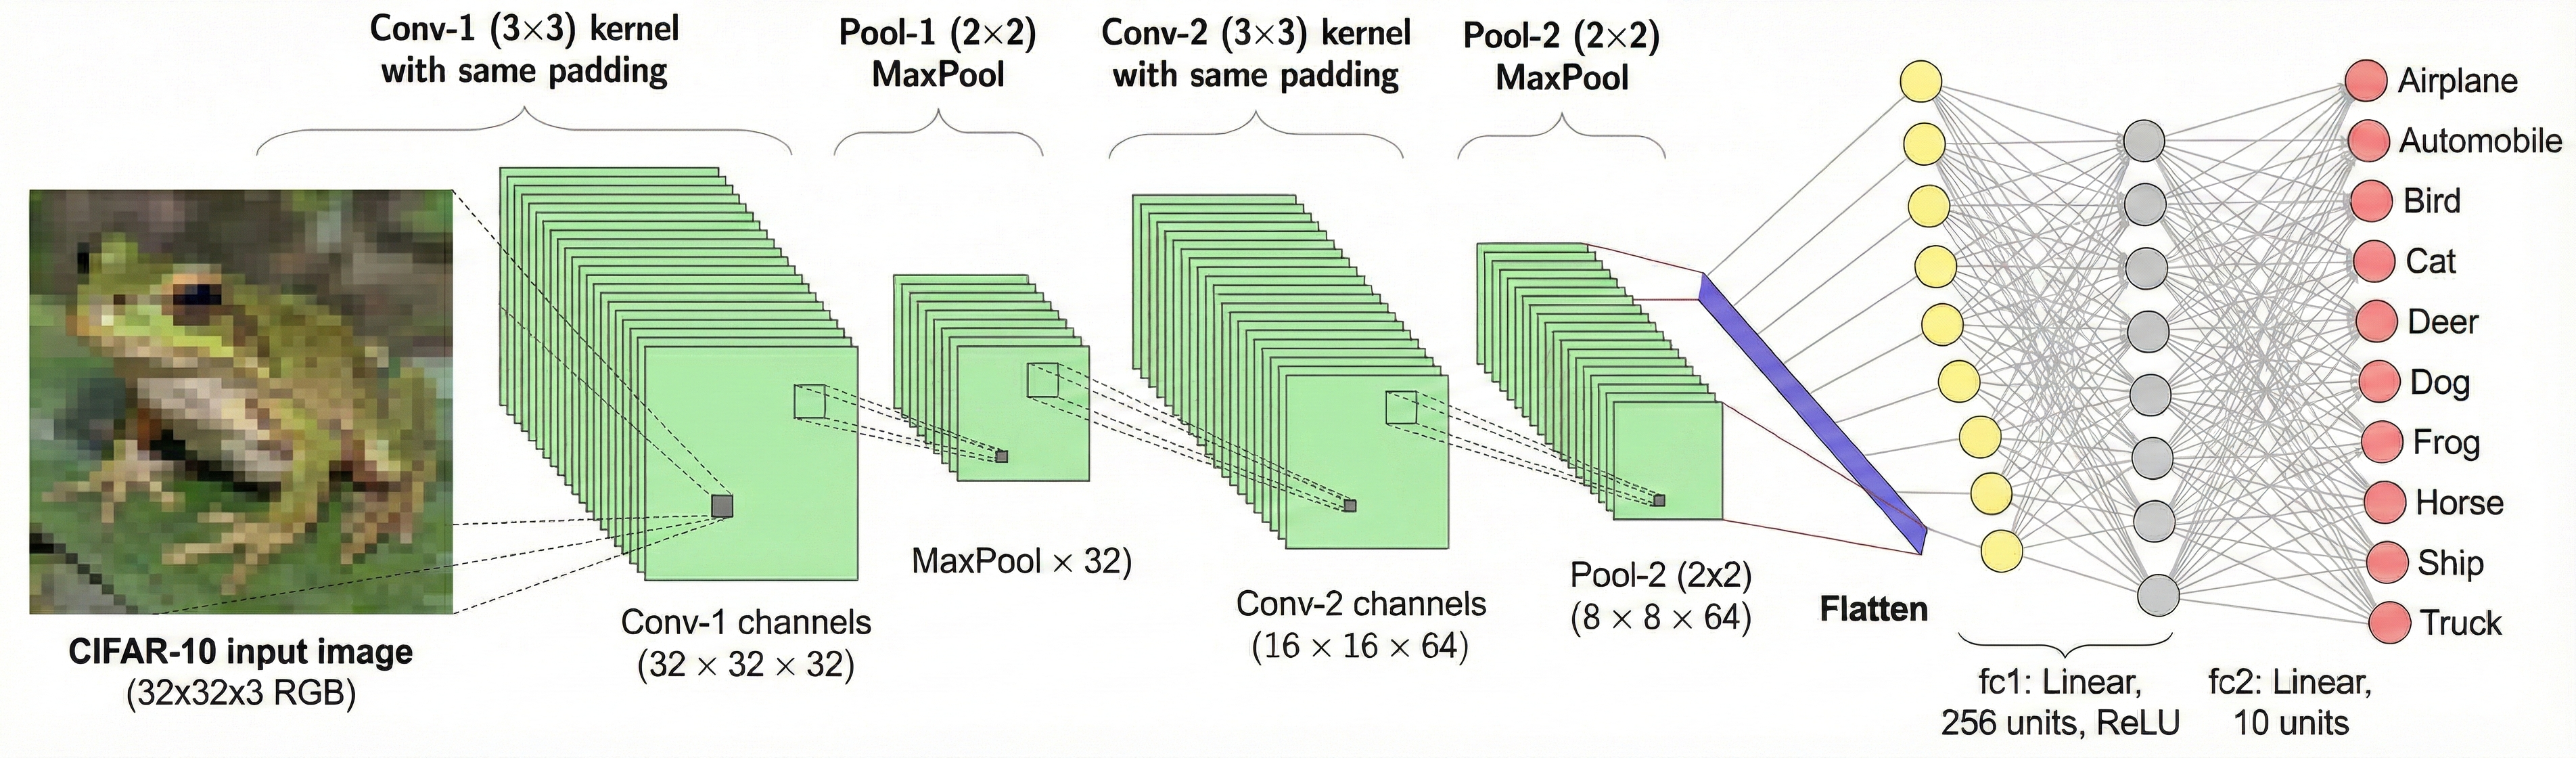

In [13]:
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


### **Written Analysis Questions**

**1. Why increasing depth could improve performance.**

Increasing depth can improve performance because deeper CNNs learn hierarchical features (edges -> textures -> parts -> objects) and increase the effective receptive field, which helps capture more complex patterns.

**2. Under what conditions deeper networks may hurt performance.**

Deeper networks may hurt performance when the dataset is small/noisy, when the task is simple, or when training is unstable (vanishing gradients) and overfitting appears due to excessive capacity.

**3. How could dropout, batch normalization, or data augmentation help?**

Dropout reduces co-adaptation and overfitting, batch normalization stabilizes training and allows higher learning rates, and data augmentation increases sample diversity to improve generalization.

**4. How would you determine whether your CNN is overfitting or underfitting?**

By comparing training vs validation curves: overfitting shows high train accuracy with lower validation accuracy and rising validation loss; underfitting shows both train and validation accuracy low with high loss.

**5. Which architectural components most impact computational cost?**

Convolutional layers with large feature maps and many channels dominate compute, followed by large fully connected layers; kernel size, number of filters, and input resolution are the main drivers.

**6. Whether the accuracy gain justifies the added complexity in a real-world deployment scenario.**

It depends on constraints: if the accuracy gain is small and latency/compute/memory are limited (e.g., edge devices), the added complexity may not be justified; in high-stakes or server settings, a measurable gain can be worth it.

## **Grading Rubric (10 points)**

| Criterion | Points |
|------------|--------|
| **Baseline Reproduction** – Correct implementation and training of the provided baseline CNN. Clear report of baseline accuracy and training setup. | 1 |
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 2 |
| **Written Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
| **Experimental Design & Comparison** – Systematic comparison between baseline and modified model (same dataset split, controlled variables, reported metrics). Includes training/validation accuracy curves. | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. <br>• +1% improvement: 0.5 pts <br>• +2% improvement: 1 pt | 1 |
| **Generalization Analysis** – Discussion of overfitting/underfitting behavior and the role of regularization techniques (BatchNorm, Dropout, data augmentation, etc.). | 1 |
| **Computational Tradeoff Reflection** – Analysis of parameter count, training time, and whether the accuracy gain justifies the added complexity. | 1 |
| **Code Clarity & PyTorch Best Practices** – Clean modular implementation (proper use of `nn.Module`, readable forward pass, reproducibility practices). | 1 |
| **Total** | **10** |

---

### Notes

- Simply increasing the number of filters without justification will not receive full architectural credit.
- Accuracy alone does not guarantee a high grade — reasoning and analysis are weighted heavily.
- Extra credit (+0.5) may be awarded for implementing advanced concepts (e.g., residual blocks, learning rate scheduling experiments, or ablation studies). Applies just for students with <10 points.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>